# <u> Project Description <u>

This project performs an end-to-end analysis of the US Superstore dataset using Python. The analysis includes data cleaning, exploratory data analysis (EDA), statistical hypothesis testing, and business intelligence techniques to evaluate sales performance, profitability, customer behavior, and operational efficiency. The goal is to transform raw transactional data into meaningful business insights and provide actionable recommendations that support strategic decision-making.

# <u> Problem Statement <u>

The US Superstore generates thousands of sales transactions across multiple product categories, customer segments, and geographic regions. Despite strong sales, the company faces inconsistent profitability due to varying discount strategies, product performance, and regional differences. The business lacks clear visibility into the factors driving revenue and profit, making it difficult to optimize operations and maximize returns.

The objective of this project is to analyze historical sales data to identify the key drivers of sales and profit, uncover underperforming products and regions, evaluate the impact of discounts on profitability, and provide data-driven recommendations that help improve operational efficiency, customer satisfaction, and overall business performance.

In [54]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt 
import seaborn as sns
import pingouin as pg
pd.set_option('display.max_columns', None)

In [55]:
orders = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Super Store Data/CSV/Orders csv.csv')
returns = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Super Store Data/CSV/Return csv.csv')
users = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Super Store Data/CSV/User csv.csv')

In [56]:
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,Product Sub-Category,Product Base Margin,Country,Region,State or Province,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,Pens & Art Supplies,0.54,United States,West,Washington,2015-01-07,2015-01-08,4.56,4,13.01,88522
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,Chairs & Chairmats,0.60,United States,West,California,2015-06-13,2015-06-15,4390.37,12,6362.85,90193
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,Office Furnishings,0.45,United States,East,New Jersey,2015-02-15,2015-02-17,-53.81,22,211.15,90192
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,Office Furnishings,0.43,United States,Central,Minnesota,2015-05-12,2015-05-14,803.47,16,1164.45,86838
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,Pens & Art Supplies,0.56,United States,Central,Minnesota,2015-05-12,2015-05-13,-24.03,7,22.23,86838


In [57]:
returns.head()

,Order ID,Status
0,65,Returned
1,612,Returned
2,614,Returned
3,678,Returned
4,710,Returned


In [58]:
users.head()

,Region,Manager
0,Central,Chris
1,East,Erin
2,South,Sam
3,West,William


# <u> Data Cleaning and Preparation <u>

## Orders Table

In [59]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                1952 non-null   int64  
 1   Order Priority        1952 non-null   object 
 2   Discount              1952 non-null   float64
 3   Unit Price            1952 non-null   float64
 4   Shipping Cost         1952 non-null   float64
 5   Customer ID           1952 non-null   int64  
 6   Customer Name         1952 non-null   object 
 7   Ship Mode             1952 non-null   object 
 8   Customer Segment      1952 non-null   object 
 9   Product Category      1952 non-null   object 
 10  Product Sub-Category  1952 non-null   object 
 11  Product Base Margin   1936 non-null   float64
 12  Country               1952 non-null   object 
 13  Region                1952 non-null   object 
 14  State or Province     1952 non-null   object 
 15  Order Date           

In [92]:
orders = orders.rename(columns = {'Quantity ordered new' : 'Quantity Ordered'})

**Data Structure Validation**  
The dataset structure was examined using the info() function to verify the number of records, data types, and the completeness of each variable. This validation step ensured that the dataset contained the appropriate data types for numerical and categorical variables while identifying any missing values that required attention before analysis.

**Key Observations**  
- The dataset consists of 1,952 transaction records across 21 variables, providing comprehensive information on customer orders, products, shipping, sales, and profitability.
- Numerical variables are stored using appropriate integer and floating-point data types, while descriptive attributes such as customer details, product information, and geographical locations are stored as categorical (object) variables.
- Both Order Date and Ship Date were initially stored as object data types and required conversion to datetime format during data preparation to support time-based analysis.
- Only the Product Base Margin column contained missing values (16 records), while all other variables were complete.

**Conclusion**  
The dataset structure was successfully validated, confirming that the variables were appropriately organized for analysis. The inspection identified a small number of missing values in the Product Base Margin column and highlighted the need to convert the date fields into datetime format. Apart from these minor preprocessing requirements, the dataset demonstrated a high level of completeness and was well-suited for subsequent data preparation, exploratory analysis, and statistical testing.

In [60]:
orders.isna().sum()

Row ID                   0
Order Priority           0
Discount                 0
Unit Price               0
Shipping Cost            0
Customer ID              0
Customer Name            0
Ship Mode                0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Base Margin     16
Country                  0
Region                   0
State or Province        0
Order Date               0
Ship Date                0
Profit                   0
Quantity ordered new     0
Sales                    0
Order ID                 0
dtype: int64

Product Base Margin contained 16 missing values. Since the column was not used in the scope of this analysis and the missing values could not be accurately derived from the available transaction data, no imputation was performed. The original values were retained to preserve data integrity.

In [61]:
orders.describe()

,Row ID,Discount,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Profit,Quantity ordered new,Sales,Order ID
count,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1936.000000,1952.000000,1952.000000,1952.000000,1952.000000
mean,19916.479508,0.048975,109.079221,12.968151,1735.376537,0.515186,114.793858,12.944672,985.828832,82365.924180
std,5957.595627,0.031378,393.481301,17.414631,991.078006,0.137055,1141.112401,13.871565,2559.900167,19042.295798
min,64.000000,0.000000,1.140000,0.490000,3.000000,0.350000,-16476.840000,1.000000,2.250000,359.000000
25%,19121.000000,0.020000,6.480000,3.230000,875.000000,0.380000,-84.487500,5.000000,58.807500,86767.750000
50%,21164.500000,0.050000,20.990000,6.150000,1738.000000,0.525000,1.480000,10.000000,202.395000,88376.000000
75%,23483.250000,0.080000,100.972500,14.362500,2578.250000,0.590000,116.202500,16.000000,802.945000,89957.000000
max,26389.000000,0.210000,6783.020000,164.730000,3403.000000,0.850000,9228.230000,167.000000,45737.330000,91586.000000


**Key Observations**  
- The dataset contains 1,952 complete order transactions, with Product Base Margin having 16 missing values, while all remaining numerical columns are complete.
- Sales exhibit high variability, ranging from 1.14 to 6,783.02, indicating the presence of both low-value and high-value orders.
- Profit ranges from a loss of 16,476.84 to a profit of 9,228.23, suggesting that certain transactions generated significant financial losses despite recorded sales.
- The average discount offered is 4.9%, with discounts reaching a maximum of 21%, making discounting a potential factor influencing profitability.
- Shipping costs show substantial variation, ranging from 2.25 to 45,737.33, highlighting differences in order size, shipping methods, or delivery requirements.
- The Product Base Margin averages 51.5%, indicating moderate profitability across the product portfolio.

**Conclusion**  
The dataset was successfully validated and prepared for analysis by identifying missing values, verifying data types, reviewing summary statistics, and examining the distribution of numerical variables. Minor data quality issues, such as missing values in the Product Base Margin column, were identified and appropriately handled, while all other variables were found to be complete and consistent. The validation process also highlighted the presence of substantial variation and potential outliers in key business metrics such as Sales, Profit, and Shipping Cost. Overall, the dataset was deemed reliable and suitable for exploratory data analysis and subsequent statistical hypothesis testing.

In [62]:
orders['Order Priority'] = orders['Order Priority'].str.strip()
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])
orders['Order Month'] = orders['Order Date'].dt.month
orders.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,Product Sub-Category,Product Base Margin,Country,Region,State or Province,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID,Order Month
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,Pens & Art Supplies,0.54,United States,West,Washington,2015-01-07,2015-01-08,4.56,4,13.01,88522,1
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,Chairs & Chairmats,0.60,United States,West,California,2015-06-13,2015-06-15,4390.37,12,6362.85,90193,6
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,Office Furnishings,0.45,United States,East,New Jersey,2015-02-15,2015-02-17,-53.81,22,211.15,90192,2
3,24844,Medium,0.09,78.69,19.99,14,Gwendolyn F Tyson,Regular Air,Small Business,Furniture,Office Furnishings,0.43,United States,Central,Minnesota,2015-05-12,2015-05-14,803.47,16,1164.45,86838,5
4,24846,Medium,0.08,3.28,2.31,14,Gwendolyn F Tyson,Regular Air,Small Business,Office Supplies,Pens & Art Supplies,0.56,United States,Central,Minnesota,2015-05-12,2015-05-13,-24.03,7,22.23,86838,5


**Date Formatting and Feature Engineering**  
To prepare the dataset for time-based analysis, the Order Priority column was standardized by removing leading and trailing whitespace to ensure consistent category values. The Order Date and Ship Date columns were converted from text to the appropriate datetime format, enabling chronological analysis and date-based calculations. Additionally, a new variable, Order Month, was derived from the Order Date to facilitate monthly sales and profit trend analysis as well as seasonal statistical comparisons.

**Actions Performed**  
- Removed unnecessary whitespace from the Order Priority column to standardize categorical values.
- Converted Order Date to datetime format.
- Converted Ship Date to datetime format.
- Created a new Order Month feature by extracting the month from the Order Date.

**Conclusion**  
These preprocessing steps ensured that categorical values were clean and consistent while transforming date fields into a format suitable for temporal analysis. The newly created Order Month variable enabled month-wise exploratory analysis and hypothesis testing, supporting the identification of seasonal trends and business performance patterns.

# <u> Hypothesis Testing and Statistical Analysis <u>

## Normality Check

In [63]:
pg.normality(orders)

,W,pval,normal
Row ID,0.737215,3.534410e-48,False
Discount,0.944086,1.429041e-26,False
Unit Price,0.218855,2.130222e-67,False
Shipping Cost,0.663948,3.157732e-52,False
Customer ID,0.952107,8.911044e-25,False
Product Base Margin,0.899929,8.534473e-34,False
Profit,0.474313,5.005250e-60,False
Quantity ordered new,0.682399,2.779865e-51,False
Sales,0.366838,1.958883e-63,False
Order ID,0.449809,7.478843e-61,False


**Conclusion**  
The normality assessment confirmed that the numerical variables in the Super Store dataset do not follow a normal distribution. Based on these findings, non-parametric statistical methods, such as the Kruskal–Wallis H Test and Mann–Whitney U Test, were selected where appropriate because they do not require the assumption of normality. However, for analyses involving large sample sizes and categorical group comparisons, tests such as ANOVA and Chi-Square were also applied where their underlying assumptions were reasonably satisfied or where the tests are known to be robust to deviations from normality. This ensured that each statistical technique was chosen based on its suitability for the data and the research objective.

# 1. Does the Order Month Significantly Influence Sales and Profit?

**Objective**  
The objective of this analysis is to determine whether Sales and Profit vary significantly across different Order Months. Identifying statistically significant monthly differences helps evaluate the presence of seasonal trends, demand fluctuations, and variations in business performance throughout the year. The findings can support inventory planning, marketing campaigns, pricing strategies, and resource allocation during peak and low-performing months.

**Null Hypothesis (H₀):** There is no statistically significant difference in Sales and Profit across different Order Months. Any observed variation is due to random chance.

**Alternative Hypothesis (H₁):** There is a statistically significant difference in Sales and/or Profit across different Order Months, indicating that business performance varies by month.

In [64]:
sales_result = pg.kruskal(data = orders, dv = 'Sales', between = 'Order Month')
profit_result = pg.kruskal(data = orders, dv = 'Profit', between = 'Order Month')

sales_result['Column'] = 'Sales'
profit_result['Column'] = 'Profit'

result = pd.concat([sales_result, profit_result], ignore_index = True)
result

,Source,ddof1,H,p_unc,Column
0,Order Month,5,14.725703,0.011601,Sales
1,Order Month,5,30.274802,0.000013,Profit


**Interpretation**  
The Kruskal–Wallis H Test indicates statistically significant differences in both Sales and Profit across the six Order Months analyzed.
Sales showed a statistically significant monthly variation (H = 14.726, p = 0.0116), suggesting that sales performance differs across months rather than remaining consistent throughout the period.
Profit exhibited an even stronger monthly difference (H = 30.275, p < 0.001), indicating that profitability fluctuates considerably between months.
Since both p-values are below the significance level of 0.05, the null hypothesis is rejected for both variables. These findings suggest that month is a significant factor influencing business performance, with certain months generating higher or lower sales and profits than others.

**Conclusion**  
The analysis confirms that Sales and Profit are not uniformly distributed across Order Months. The significant monthly differences indicate the presence of seasonal or time-related business patterns that may influence customer purchasing behavior and overall profitability. These findings justify conducting post-hoc pairwise comparisons (Dunn's Test) to identify the specific months that differ significantly from one another, providing deeper insights for business planning and decision-making.

In [65]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    orders,
    val_col='Profit',
    group_col='Order Month',
    p_adjust='bonferroni'
)

dunn

,1,2,3,4,5,6
1,1.000000,0.404059,1.000000,0.018087,0.000006,0.163961
2,0.404059,1.000000,1.000000,1.000000,0.085859,1.000000
3,1.000000,1.000000,1.000000,0.604697,0.001745,1.000000
4,0.018087,1.000000,0.604697,1.000000,1.000000,1.000000
5,0.000006,0.085859,0.001745,1.000000,1.000000,0.238707
6,0.163961,1.000000,1.000000,1.000000,0.238707,1.000000


# 1.1. Post-hoc Analysis: Dunn's Test (Profit)

**Objective**  
Following the significant Kruskal–Wallis test result, Dunn's Post-hoc Test with Bonferroni correction was conducted to identify the specific pairs of Order Months that exhibited statistically significant differences in Profit.

**Interpretation**  
- The post-hoc analysis indicates that Profit remained relatively consistent across most months, with statistically significant differences observed in only three out of fifteen pairwise comparisons.
- Month 5 differed significantly from both Month 1 and Month 3, suggesting that profitability during Month 5 was substantially different from these periods.
- A significant difference was also observed between Month 1 and Month 4, indicating changes in profitability between the beginning and later stages of the observed period.
- No significant differences were found among the remaining month pairs, implying relatively stable profit performance across those months.

**Business Insights**  
- Profitability is not uniform throughout the year, with certain months performing significantly differently from others.
- The strongest statistical difference was observed between Month 1 and Month 5 (p = 0.000006), highlighting a pronounced change in business profitability.
- Since only a limited number of month pairs showed significant differences, the observed seasonality appears to be concentrated in specific periods rather than occurring consistently across all months.

**Business Recommendations**   
- Investigate the operational, promotional, or market factors contributing to the significant profitability differences observed in Months 4 and 5.
- Review pricing strategies, discount policies, inventory availability, and customer demand during these months to identify potential drivers of performance.
- Use insights from the higher-performing months to optimize marketing campaigns, inventory planning, and sales strategies during comparatively weaker periods.
- Continue monitoring monthly profit trends to identify recurring seasonal patterns and support data-driven forecasting and resource allocation.

# 2. Analysing the Avg Sales and Profit Breakdown by Month 

In [66]:
# Monthly Sales Analysis
months = orders.groupby('Order Month')[['Sales', 'Profit']].sum().reset_index()
month_map = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

months['Order Month'] = months['Order Month'].map(month_map)
months

,Order Month,Sales,Profit
0,January,274766.92,1043.61
1,February,326101.47,35944.66
2,March,271696.67,103.16
3,April,389831.95,53146.47
4,May,306572.07,67002.74
5,June,355368.80,66836.97


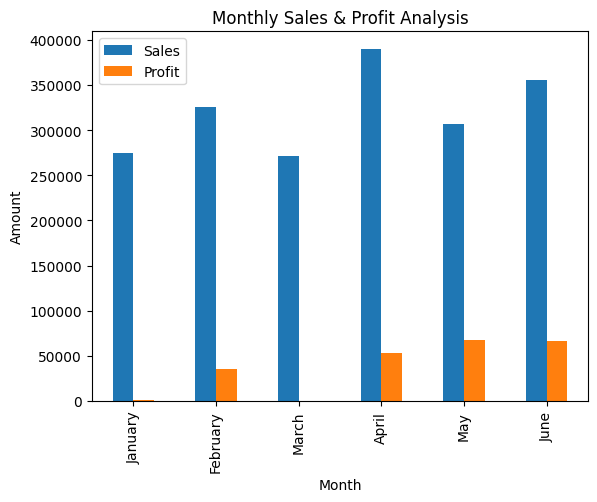

In [67]:
months.plot(kind='bar', x = 'Order Month')

plt.title('Monthly Sales & Profit Analysis')
plt.xlabel('Month')
plt.ylabel('Amount')

plt.show()

# 3. Monthly Sales Performance and Order Volume Analysis
**Objective**  
To evaluate monthly business performance by comparing key sales and operational KPIs, including total sales, total orders, total quantity sold, average order value, and average items per order, in order to identify the factors influencing monthly sales performance.

In [106]:
summary = orders.groupby('Order Month').agg(
    total_quantity = ('Quantity Ordered', 'sum'), 
    total_sales = ('Sales', 'sum'), 
    total_orders = ('Order Month', 'count'))

summary['avg_order_value'] = (summary['total_sales'] / summary['total_orders']).round(2)
summary['avg_items_order'] = (summary['total_quantity']/ summary['total_orders']).round(0)

summary

,total_quantity,total_sales,total_orders,avg_order_value,avg_items_order
Order Month,,,,,
1,3368,274766.92,370,742.61,9.0
2,4220,326101.47,314,1038.54,13.0
3,3592,271696.67,328,828.34,11.0
4,3955,389831.95,321,1214.43,12.0
5,5813,306572.07,313,979.46,19.0
6,4320,355368.80,306,1161.34,14.0


**Interpretation**  
- January recorded the lowest Average Order Value (₹742.61) despite processing the highest number of customer orders (370). This indicates that customers placed more frequent but lower-value purchases during the month.
- March generated the lowest Total Sales (₹271,696.67). However, the month did not record the lowest number of orders, suggesting that the lower monthly revenue cannot be attributed solely to reduced customer demand.
- April achieved the highest Total Sales (₹389,831.95) while maintaining a moderate order volume (321 orders). This indicates stronger revenue generation through higher-value transactions rather than increased customer traffic.
- May recorded the highest Average Items per Order (approximately 19 items) despite only 313 orders. This suggests customers purchased significantly more products per transaction, although the overall Average Order Value remained lower than April, indicating purchases were concentrated on relatively lower-priced products.
- June maintained one of the highest Average Order Values (₹1,161.34) while processing the fewest customer orders (306). This demonstrates that larger transaction values compensated for the lower order volume.
- Across the six-month period, monthly performance was influenced by a combination of order volume and customer spending per transaction, rather than either factor individually.

**Business Insights**  
- Order volume alone did not determine monthly revenue. Months with fewer orders (April and June) generated substantially higher sales through higher-value transactions.
- January's weaker sales performance was primarily driven by lower spending per order rather than insufficient customer demand.
- March's lower total sales resulted from a combination of moderate order volume and only average transaction values, indicating opportunities to increase both customer purchasing behaviour and transaction size.
- Increasing Average Order Value (AOV) appears to have a greater impact on revenue growth than simply increasing the number of customer orders.

**Business Recommendations**  
- Introduce cross-selling and upselling strategies during lower-performing months, particularly January and March, to increase the average value of each customer transaction.
- Design bundle offers and product recommendations to encourage customers to purchase higher-value products alongside their existing purchases.
- Investigate the business practices, promotional campaigns, and product mix implemented during April, when the business achieved its highest Average - Order Value and Total Sales, and replicate successful strategies in lower-performing months.
- Monitor Average Order Value, Total Orders, and Average Items per Order as core monthly KPIs, as these metrics collectively provide a comprehensive view of sales performance and customer purchasing behaviour.

# 3.1 Are customer order values in January(1) significantly lower than those recorded during the remaining months?
**Objective**  
To determine whether individual customer order values in January were significantly lower than those recorded during the remaining months.  

**Null Hypothesis (H₀)** Individual customer order values in January are equal to or greater than those recorded during the remaining months.  
**Alternative Hypothesis (H₁)** Individual customer order values in January are significantly lower than those recorded during the remaining months.

In [109]:
jan_sales = orders.loc[
    orders['Order Month'] == 1,
    'Sales'
]

other_sales = orders.loc[
    orders['Order Month'] != 1,
    'Sales'
]

pg.mwu(
    x=jan_sales,
    y=other_sales,
    alternative='less'
)

,U_val,alternative,p_val,RBC,CLES
MWU,259268.5,less,0.000311,-0.114127,0.557063


**Business Insights**  
- January recorded the lowest average order value (₹742.61) among all months, and the statistical test confirms that this was not due to random variation.
- Although January processed the highest number of customer orders (370), customers spent significantly less per transaction, resulting in relatively lower monthly revenue.
- This indicates that January's sales performance was primarily constrained by lower customer spending per order rather than insufficient customer demand.

**Business Recommendations**  
- Implement upselling and cross-selling strategies during January to increase the value of each transaction.
- Introduce bundle offers, premium product recommendations, and volume discounts to encourage customers to purchase higher-value baskets.
- Analyze product categories and promotional campaigns during January to identify factors contributing to lower order values and adjust pricing or marketing strategies accordingly.
- Track Average Order Value (AOV) as a key monthly KPI, as increasing transaction value may have a greater impact on revenue than focusing solely on increasing order volume.

Although January's order values were significantly lower than those in the remaining months (p < 0.001), the effect size was small (RBC = -0.114), indicating that the difference, while consistent, was modest in magnitude.

# 4. Order Priority Distribution by Sales
**Objective**  
To evaluate how total sales are distributed across different order priority levels and identify which priority categories contribute the most to overall business revenue.

<Axes: xlabel='Order Priority'>

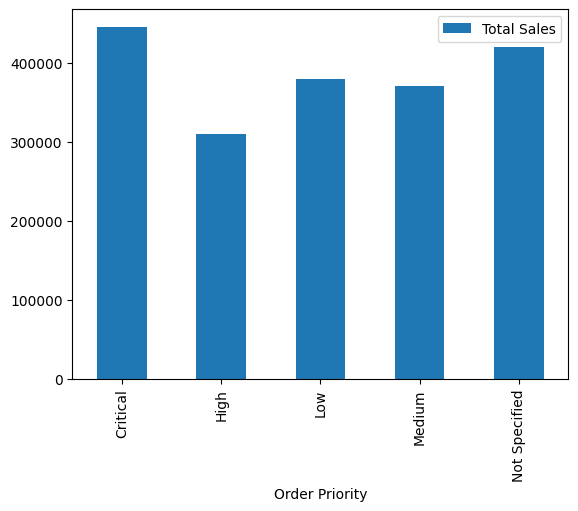

In [111]:
op = orders.groupby('Order Priority')['Sales'].sum().reset_index(name = 'Total Sales')
op.plot(x = 'Order Priority', y = 'Total Sales', kind = 'bar')

**Interpretation**  
- Critical orders generated the highest total sales (445,010.03), making them the largest contributor to overall revenue. This suggests that orders requiring immediate attention are also among the highest-value transactions.
- Not Specified orders recorded the second-highest total sales (420,026.22), indicating that a considerable portion of revenue is generated from orders without an assigned priority. This may point to inconsistencies in order classification or incomplete operational processes.
- Low and Medium priority orders contributed similar sales, generating 379,127.34 and 370,078.81, respectively. This indicates a relatively balanced revenue contribution between these two operational categories.
- High priority orders generated the lowest total sales (310,095.48), despite representing an important operational priority. This suggests that high-priority orders are not necessarily the highest-value transactions.

**Business Insights**  
- Revenue is not directly proportional to order priority. Critical orders contribute the most revenue, while High priority orders contribute the least.
- The substantial revenue generated by Not Specified orders highlights a potential issue in order management, as missing priority classifications may hinder effective resource allocation and service-level monitoring.
- The relatively even contribution from Low and Medium priority orders suggests these segments provide stable revenue and should continue to receive consistent operational support.

**Business Recommendations**  
- Prioritize the efficient processing of Critical orders to protect a significant proportion of business revenue.
- Investigate why a large share of sales is associated with Not Specified priority orders. Implement mandatory order-priority assignment during order creation to improve reporting accuracy and operational planning.
- Review the criteria used to classify High priority orders to ensure they accurately reflect business importance and customer urgency.
- Monitor revenue by order priority as a recurring KPI to support workforce planning, service-level management, and operational decision-making.

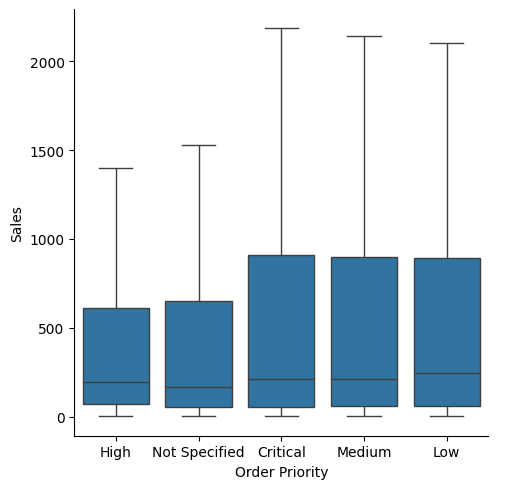

In [70]:
sns.catplot(x = 'Order Priority', y = 'Sales', data = orders, kind = 'box', showfliers = False)

**Interpretation**  
- Critical orders exhibit the widest distribution of sales values, indicating substantial variability in transaction sizes. While many orders are of relatively low value, the category also contains numerous high-value transactions, contributing to its highest overall sales.
- Medium and Low priority orders show distributions similar to Critical orders, with higher upper quartiles and wider ranges than High and Not Specified priorities. This suggests these categories also include a considerable number of large-value transactions.
- High priority orders display the smallest spread in sales values and a comparatively lower upper whisker, indicating that most transactions are concentrated within a narrower sales range and fewer exceptionally large orders occur.
- The median sales values across all priority categories are relatively similar, with only slight differences. This indicates that a typical order has a comparable sales value regardless of its assigned priority.
- The larger differences occur in the upper half of the distributions, where Critical, Medium, and Low priority orders contain more high-value purchases than High priority orders.

**Business Insights**  
- The higher total sales generated by Critical orders appear to be driven by the presence of more high-value transactions, rather than a substantially higher median order value.
- Since the medians are similar across categories, order priority is not a strong indicator of the typical transaction value.
- High-value orders are distributed across several priority levels, suggesting that operational priority is influenced by factors beyond sales value alone (e.g., delivery urgency, customer requirements, or service agreements).
- The absence of displayed outliers (because showfliers=False) means the visible differences reflect the main body of the data rather than a few extreme observations.

**Business Recommendations**
- Continue prioritizing Critical orders, as they contain a higher proportion of large-value transactions that contribute significantly to revenue.
- Review the criteria used to assign order priorities to ensure that high-value customer orders are appropriately classified and receive the required operational attention.
- Analyze additional factors (e.g., customer segment, product category, shipping mode) alongside order priority to better understand what drives high-value sales.
- Monitor both median and distribution of sales values by priority, rather than relying solely on total sales, to gain a more complete understanding of customer purchasing behaviour.

# 4.1 Does Order Priority Significantly Influence Customer Order Sales?
**Objective**  
The objective of this analysis is to determine whether customer order sales differ significantly across different order priority categories. Understanding whether order priority is associated with variations in sales can help evaluate if high-value transactions are concentrated within specific priority levels or are distributed consistently across all orders. The findings can support operational planning, resource allocation, order processing strategies, and prioritization policies to improve overall business efficiency.

**Null Hypothesis (H₀)** There is no statistically significant difference in customer order sales across the different order priority categories. Any observed variation in sales is due to random chance.

**Alternative Hypothesis (H₁)** There is a statistically significant difference in customer order sales across at least one order priority category, indicating that customer order values vary depending on the assigned order priority.

In [114]:
pg.kruskal(data = orders, dv = 'Sales', between = 'Order Priority')

,Source,ddof1,H,p_unc
Kruskal,Order Priority,4,1.949222,0.745098


**Interpretation**  
- The Kruskal–Wallis test produced an H statistic of 1.949 with a p-value of 0.745.
- Since the p-value is greater than the significance level of 0.05, the null hypothesis cannot be rejected.
- There is no statistically significant difference in customer order sales across the different order priority categories.
- Although the box plot showed slight differences in the spread of sales values, these differences are not statistically significant and are likely due to natural variation within the data.
- This indicates that order priority does not have a meaningful influence on the sales value of individual customer orders.

**Business Insights**  
- Customer order values are distributed similarly across all order priority categories, suggesting that high-value and low-value transactions occur in every priority level.
- The higher total sales observed for Critical orders are not necessarily because individual Critical orders have higher sales values. Instead, they may result from factors such as a greater number of transactions or the presence of a few larger orders.
- Order priority appears to reflect operational urgency rather than transaction value, indicating that priority assignments are likely based on business processes rather than the monetary value of orders.

**Business Recommendations**  
- Continue assigning order priorities based on operational requirements, as there is no statistical evidence that higher-priority orders consistently generate larger sales values.
- Do not use order priority alone as an indicator of revenue potential when allocating operational resources or forecasting sales.
- To better understand revenue differences between priority levels, analyze additional factors such as order frequency, product categories, customer segments, shipping methods, or regional sales performance.
- Monitor order priority alongside other business KPIs rather than relying on sales value alone to evaluate operational performance.

# 5. Does Region Significantly Influence Customer Order Sales?
**Objective**  
The objective of this analysis is to determine whether customer order sales vary significantly across different geographical regions. Identifying statistically significant regional differences helps evaluate whether business performance differs by market location, enabling the organization to understand regional demand patterns, optimize sales strategies, improve inventory allocation, and prioritize investments in high-performing markets.

**Null Hypothesis (H₀)** There is no statistically significant difference in customer order sales across the different regions. Any observed variation in sales is due to random chance.

**Alternative Hypothesis (H₁)** There is a statistically significant difference in customer order sales across at least one region, indicating that business performance varies by geographical location. 

<Axes: xlabel='Region'>

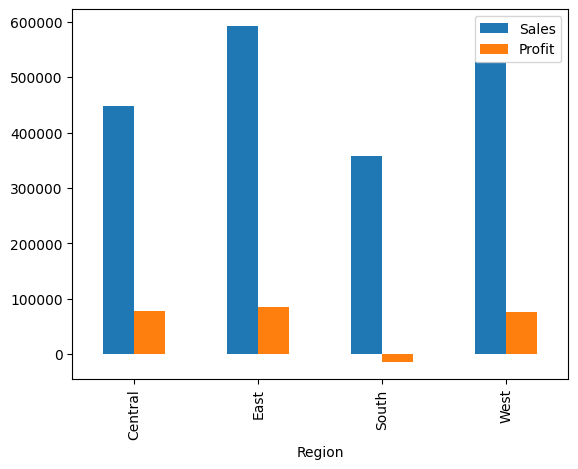

In [143]:
regional_sales = orders.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
regional_sales.plot(kind = 'bar', x = 'Region')

**Interpretation**  
- The East region generated the highest total sales (592,171.49) and also recorded the highest total profit (85,291.41), making it the strongest performing region overall.
- The West region ranked second in total sales (526,776.57) and achieved a healthy profit of 75,844.79, indicating strong revenue generation with good profitability.
- The Central region contributed 448,284.70 in sales and generated 77,365.49 in profit, producing a profit level comparable to the West despite lower sales.
- The South region recorded the lowest sales (357,105.12) and was the only region to incur an overall loss (-14,424.08), indicating that its sales were insufficient to cover associated costs.

**Business Insights**  
- The East region serves as the company's highest-performing market, contributing both the greatest revenue and the highest profitability.
- Although the West generated substantially higher sales than the Central region, both produced similar profit levels, suggesting differences in cost structures, pricing strategies, discounting, or product mix.
- The South region's negative profit despite generating over 357,000 in sales highlights a significant profitability issue. This suggests that factors such as excessive discounts, high shipping costs, increased returns, or sales of low-margin products may be eroding profitability.
- The variation between regional sales and profit indicates that higher revenue does not always translate into higher profitability, emphasizing the need to evaluate profit alongside sales when assessing regional performance.

**Business Recommendations**  
- Prioritize investment and expansion in the East region, as it consistently delivers the strongest balance of revenue and profitability.
- Investigate the South region to identify the root causes of its negative profit by analysing discount policies, shipping expenses, product mix, operational costs, and return rates.
- Compare operational practices between the Central and West regions to understand why similar profit levels are achieved despite different sales volumes, and apply successful strategies across regions where appropriate.
- Monitor both Sales and Profit as key regional performance indicators, ensuring that business decisions focus on sustainable profitability rather than revenue growth alone.

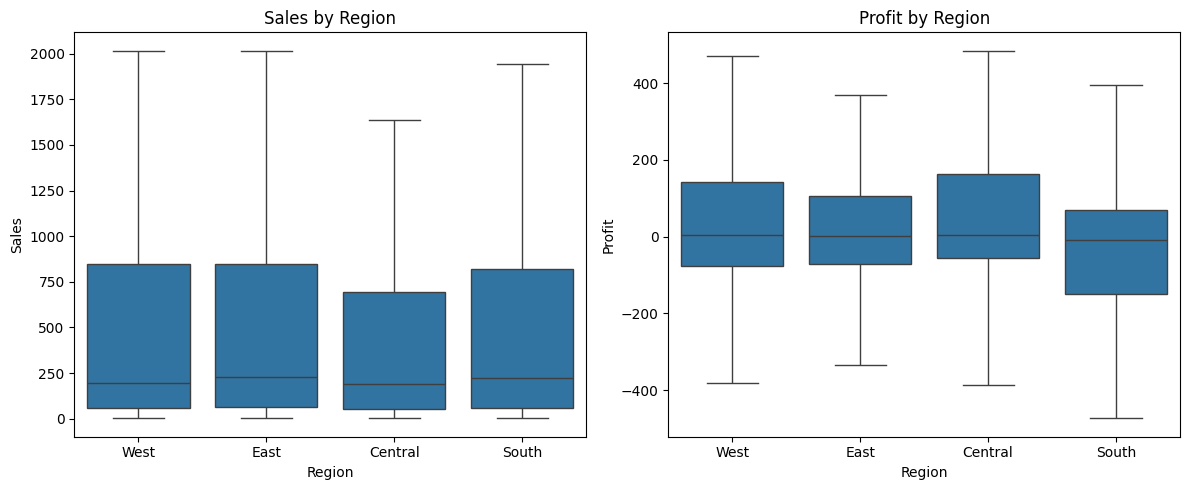

In [140]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Sales Box Plot
sns.boxplot(
    data=orders,
    x='Region',
    y='Sales',
    showfliers=False,
    ax=ax[0]
)
ax[0].set_title('Sales by Region')
ax[0].set_xlabel('Region')
ax[0].set_ylabel('Sales')

# Profit Box Plot
sns.boxplot(
    data=orders,
    x='Region',
    y='Profit',
    showfliers=False,
    ax=ax[1]
)
ax[1].set_title('Profit by Region')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

## Interpretation 
**Sales by Region**
- The East and South regions have slightly higher median sales than the West and Central regions, although the differences are relatively small.
- All four regions exhibit wide interquartile ranges (IQRs), indicating substantial variability in customer order values within each region.
- The whiskers extend to similar maximum sales values across regions, suggesting that large-value orders occur throughout all geographical markets.
- The considerable overlap between the box plots indicates that the distribution of customer order sales is broadly similar across regions.  

**Profit by Region**
- Median profit is close to zero for all regions, indicating that a typical customer order generates relatively modest profit regardless of location.
- The Central region shows the widest spread in profit, suggesting greater variability in profitability between individual orders.
- The South region has a lower median profit and a larger proportion of negative-profit orders compared with the other regions, which is consistent with its overall negative total profit.
- Despite differences in total regional profit, the distributions overlap considerably, implying that profitable and unprofitable orders occur across all regions.

## Business Insights
- Customer purchasing behaviour appears to be relatively consistent across regions, with no region exhibiting a dramatically different distribution of order values.
- The South region's overall loss is unlikely to be driven by a few exceptionally poor-performing orders alone. Instead, the distribution suggests a broader profitability challenge affecting many transactions.
- The similar sales distributions across regions indicate that differences in total sales are likely influenced more by order volume than by substantially larger individual order values.
- Since the distributions overlap considerably, any apparent regional differences should be validated using a Kruskal–Wallis test before concluding that region significantly affects sales or profit.

In [147]:
regional_sales = pg.kruskal(data = orders, dv = 'Sales', between = 'Region')
regional_profit = pg.kruskal(data = orders, dv = 'Profit', between = 'Region')
regional_sales['With'] = 'Sales'
regional_profit['With'] = 'Profit'
pd.concat([regional_sales, regional_profit])

,Source,ddof1,H,p_unc,With
Kruskal,Region,3,2.843837,0.416334,Sales
Kruskal,Region,3,17.369351,0.000593,Profit


## Interpretation
**Sales**  
- The Kruskal–Wallis test produced an H statistic of 2.844 with a p-value of 0.416.
- Since the p-value is greater than 0.05, the null hypothesis cannot be rejected.
- There is no statistically significant difference in customer order sales across the four regions.
- Although the East region generated the highest total sales and the South region generated the lowest total sales, these differences are primarily due to aggregated regional performance rather than meaningful differences in individual customer order values.

**Profit**  
- The Kruskal–Wallis test produced an H statistic of 17.369 with a p-value of 0.000593.
- Since the p-value is less than 0.05, the null hypothesis is rejected.
- There is a statistically significant difference in customer order profit across at least one region.
- This indicates that while customers tend to spend similar amounts regardless of region, the profitability of those orders varies significantly between geographical markets.

**Business Insights**  
- Customer purchasing behaviour is consistent across regions, as individual order sales do not differ significantly.
- Regional differences in overall revenue are therefore more likely driven by the number of orders placed rather than customers spending more per transaction.
- In contrast, profitability varies significantly across regions, suggesting that operational factors such as discounting, shipping costs, product mix, or return rates differ by region.
- The South region's negative total profit is supported by the statistical analysis, indicating that its lower profitability is not merely due to random variation.
- Sales performance alone does not provide a complete picture of regional performance; profitability should be considered alongside revenue when evaluating business success.

**Business Recommendations**  
- Conduct a Dunn's post-hoc test on Profit to identify which specific regional pairs differ significantly in profitability.
- Investigate the South region to identify the drivers of its lower profitability, focusing on discounts, fulfilment costs, shipping expenses, product mix, and return rates.
- Since customer spending is statistically similar across regions, focus on improving operational efficiency and profit margins rather than increasing average order values.
- Continue investing in regions that demonstrate strong profitability while applying best practices to underperforming regions to improve overall financial performance.

# 6. Does Product Category Significantly Influence Customer Sales and Profit?
**Objective**  
The objective of this analysis is to determine whether customer order sales and profit differ significantly across the various product categories. Identifying statistically significant differences between product categories helps evaluate which categories contribute most to business performance and profitability. The findings can support product portfolio optimization, inventory planning, pricing strategies, and resource allocation toward high-performing product categories.

**Null Hypothesis (H₀)** There is no statistically significant difference in customer order sales and profit across the different product categories. Any observed variation is due to random chance.

**Alternative Hypothesis (H₁)** There is a statistically significant difference in customer order sales and/or profit across at least one product category, indicating that business performance varies by product category.

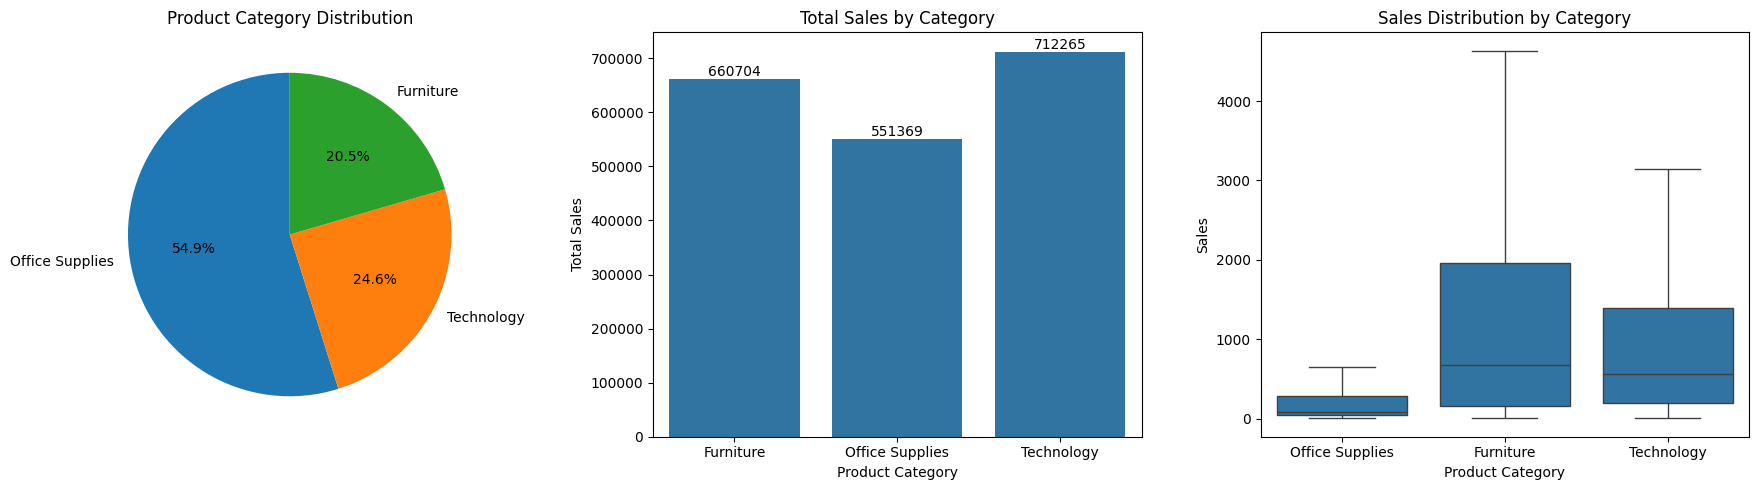

In [187]:
distribution = (
    orders['Product Category']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name='Percentage')
)

sales = (
    orders.groupby('Product Category', as_index=False)
    .agg(Total_Sales=('Sales', 'sum'))
)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ---------------- Pie Chart ----------------
ax[0].pie(
    distribution['Percentage'],
    labels=distribution['Product Category'],
    autopct='%1.1f%%',
    startangle=90
)
ax[0].set_title('Product Category Distribution')

# ---------------- Bar Chart ----------------
sns.barplot(
    data=sales,
    x='Product Category',
    y='Total_Sales',
    ax=ax[1]
)

ax[1].set_title('Total Sales by Category')
ax[1].set_xlabel('Product Category')
ax[1].set_ylabel('Total Sales')

# Add labels
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.0f')

# ---------------- Box Plot ----------------
sns.boxplot(
    data=orders,
    x='Product Category',
    y='Sales',
    showfliers=False,
    ax=ax[2]
)

ax[2].set_title('Sales Distribution by Category')
ax[2].set_xlabel('Product Category')
ax[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

## Interpretation
**Distribution Analysis**  
- Office Supplies represents the largest share of customer orders, accounting for 54.9% of all transactions.
- Technology contributes 24.6% of total orders, while Furniture accounts for 20.5%.
- Although Office Supplies dominates in purchase frequency, it generates the lowest total sales among the three categories.
- Technology records the highest total sales despite representing less than one-quarter of all orders, indicating a substantially higher average transaction value.
- Furniture also generates higher total sales than Office Supplies while accounting for a considerably smaller proportion of customer orders.

**Sales Distribution Analysis**  
- The box plot reveals substantial differences in the distribution of customer order sales across product categories.
- Office Supplies has the lowest median sales and the narrowest spread, indicating that customers typically purchase lower-value items with relatively consistent order amounts.
- Furniture exhibits the highest median sales and the greatest variability, suggesting that customer purchases range from moderate to very high-value transactions.
- Technology also demonstrates relatively high sales values and variability, although its distribution is slightly more compact than Furniture.
- These visual differences indicate that customer spending behaviour varies considerably depending on the product category.

In [160]:
distribution_sales = pg.kruskal(data = orders, between = 'Product Category', dv = 'Sales')
distribution_profit = pg.kruskal(data = orders, between = 'Product Category', dv = 'Profit')
distribution_sales['With'] = 'Sales'
distribution_profit['With'] = 'Profit'

pd.concat([distribution_sales, distribution_profit])

,Source,ddof1,H,p_unc,With
Kruskal,Product Category,2,414.700548,8.890376e-91,Sales
Kruskal,Product Category,2,8.163004,1.688209e-02,Profit


**Interpretation**  
- The Kruskal–Wallis test produced an H statistic of 414.701 with a p-value < 0.001 for Sales.
- Since the p-value is less than 0.05, the null hypothesis is rejected.
- This confirms that customer order sales differ significantly across the three product categories.
- The box plot visually supports this result, with Furniture and Technology displaying substantially higher sales distributions than Office Supplies.
- For Profit, the Kruskal–Wallis test also identified a statistically significant difference (H = 8.163, p = 0.0169), indicating that profitability varies across product categories, although the magnitude of this difference is much smaller than that observed for sales.

**Business Insights**  
- Office Supplies is the primary driver of transaction volume, suggesting it attracts repeat purchases and satisfies frequent customer needs.
- Despite accounting for more than half of all orders (54.9%), Office Supplies contributes the lowest total sales, indicating relatively low-value purchases.
- Technology generates the highest revenue with less than one-quarter of total orders, demonstrating strong revenue generation through higher-priced products.
- Furniture also produces high-value transactions despite its smaller order share, highlighting its importance as a premium product category.
- The statistically significant Kruskal–Wallis results confirm that these differences are not due to random variation, indicating that product category has a meaningful impact on both sales and profitability.
- The much larger test statistic for Sales (H = 414.701) compared with Profit (H = 8.163) suggests that product category influences revenue more strongly than profitability.

**Business Recommendations**  
- Perform a Dunn's post-hoc test to identify which specific product category pairs differ significantly in sales and profit.
- Continue investing in Technology products through targeted marketing, premium product offerings, and inventory availability, as they generate the highest revenue per transaction.
- Maintain sufficient inventory for Office Supplies, as they represent the majority of customer demand and contribute significantly to overall sales volume despite lower transaction values.
- Review pricing strategies, product bundling, and cross-selling opportunities for Office Supplies to increase average order value without reducing purchase frequency.
- Expand promotional efforts for Furniture, particularly for high-margin products, to capitalise on its strong transaction values while increasing customer demand.
- Monitor both sales performance and profitability when evaluating product categories, ensuring that revenue growth is accompanied by sustainable profit margins rather than focusing solely on order volume.

# 6.1 Dunn's Post-hoc Test (Sales)

In [194]:
import scikit_posthocs as sp

sp.posthoc_dunn(
    orders,
    val_col = 'Sales',
    group_col = 'Product Category',
    p_adjust = 'bonferroni'
    )

sp.posthoc_dunn(
    orders,
    val_col = 'Profit',
    group_col = 'Product Category',
    p_adjust = 'bonferroni'
    )


,Furniture,Office Supplies,Technology
Furniture,1.000000,1.000000,0.108429
Office Supplies,1.000000,1.000000,0.016188
Technology,0.108429,0.016188,1.000000


**Interpretation**  
- Following the significant Kruskal–Wallis test, Dunn's post-hoc test with Bonferroni correction was conducted to determine which product categories differed significantly in customer order sales.
- Office Supplies differs significantly from both Furniture (p < 0.001) and Technology (p < 0.001).
- There is no statistically significant difference between Furniture and Technology (p = 1.000).
- These findings indicate that the significant overall difference in sales is primarily driven by the substantially lower sales associated with Office Supplies, while Furniture and Technology exhibit comparable customer order sales.

**Business Insights**  
- Office Supplies drives customer demand by accounting for more than half of all transactions (54.9%), making it the highest-volume product category.
- Despite its high transaction volume, Office Supplies generates significantly lower customer order sales than both Furniture and Technology, confirming that it primarily consists of lower-value purchases.
- Technology generates the highest total sales despite representing only 24.6% of total orders, demonstrating superior revenue generation through higher-value transactions.
- The statistical analysis confirms that Sales vary much more strongly across product categories than Profit, as reflected by the substantially larger - Kruskal–Wallis statistic for Sales (H = 414.701) compared with Profit (H = 8.163).
- The post-hoc analysis further reveals that the significant sales differences are driven by Office Supplies, whereas for Profit, only Technology significantly outperforms Office Supplies.
- Furniture maintains sales performance comparable to Technology but does not differ significantly from either category in profitability, suggesting that its profit margins are more variable.

**Business Recommendations**  
- Continue investing in Technology products through targeted marketing, premium product offerings, and inventory planning, as they generate the strongest sales performance and significantly higher profits than Office Supplies.
- Increase the average order value of Office Supplies by implementing product bundles, cross-selling complementary items, and volume-based promotions rather than relying solely on increasing transaction volume.
- Maintain strong inventory availability for Office Supplies, as it remains the primary driver of customer purchases and repeat business.
- Evaluate Furniture's pricing strategy, product mix, and operational costs to improve profitability while maintaining its strong sales performance.
- Develop category-specific pricing and promotional strategies instead of applying uniform campaigns across all product categories, as customer purchasing behaviour differs significantly by category.
- Continue monitoring both sales and profit together when evaluating product performance, ensuring that revenue growth is supported by sustainable profitability rather than transaction volume alone.

# 7. Does Product Sub-Category Significantly Influence Customer Sales and Profit?
**Objective**  
The objective of this analysis is to determine whether customer order sales and profit differ significantly across the various product sub-categories within each product category. Identifying statistically significant differences among product sub-categories helps evaluate which products contribute most to revenue and profitability within their respective categories. The findings can support product assortment optimisation, inventory planning, pricing strategies, promotional planning, and resource allocation towards high-performing product sub-categories.

**Null Hypothesis (H₀)** There is no statistically significant difference in customer order sales and profit across the different product sub-categories within each product category. Any observed variation is due to random chance.

**Alternative Hypothesis (H₁)** There is a statistically significant difference in customer order sales and/or profit across at least one product sub-category within each product category, indicating that business performance varies among product sub-categories.

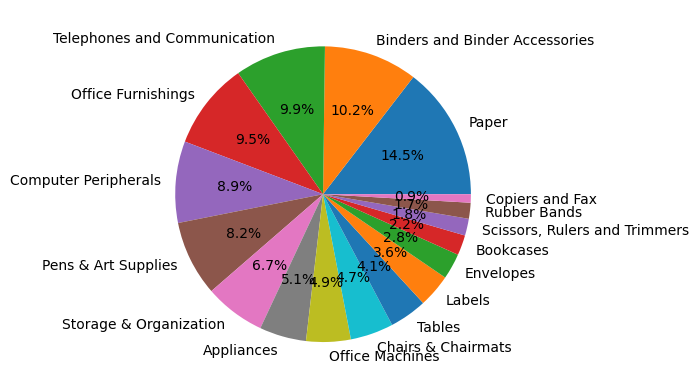

In [192]:
sub_category_dist = orders['Product Sub-Category'].value_counts(normalize = True).reset_index(name = 'Percentage')
plt.pie(sub_category_dist['Percentage'], labels = sub_category_dist['Product Sub-Category'], autopct='%1.1f%%')
plt.show()

## <u> Sales <u>

In [218]:
column = list(orders['Product Category'].unique())

def product_sub_category_kruskal(columns, between):
    result = []
    for col in columns: 
        output = pg.kruskal(data = orders[orders['Product Category'] == col], dv = between, between = 'Product Sub-Category')
        output['Product Category'] = col
        output['Judgement'] = np.where(output['p_unc'] <= 0.05, 'Rejected', 'Fail to Reject')
        result.append(output)

    return pd.concat(result, ignore_index = True)

product_sub_category_kruskal(column, 'Sales')

,Source,ddof1,H,p_unc,Product Category,Judgement
0,Product Sub-Category,8,196.175944,4.083008e-38,Office Supplies,Rejected
1,Product Sub-Category,3,169.542438,1.597518e-36,Furniture,Rejected
2,Product Sub-Category,3,102.926269,3.649283e-22,Technology,Rejected


**Interpretation**  
- The Kruskal–Wallis test was conducted separately within each Product Category to determine whether customer order Sales differ significantly across the respective Product Sub-Categories.
- The results indicate statistically significant differences in customer order sales among the product sub-categories within Office Supplies (H = 196.176, p < 0.001), Furniture (H = 169.542, p < 0.001), and Technology (H = 102.926, p < 0.001).
- Since all p-values are well below the 0.05 significance level, the null hypothesis is rejected for each product category.
- These findings suggest that customer spending is not evenly distributed across the sub-categories within each product category, indicating that some sub-categories consistently generate higher sales than others.
- Dunn's post-hoc test was subsequently performed to identify the specific sub-category pairs responsible for these significant differences.

**Business Insights**  
- Customer purchasing behaviour varies significantly across product sub-categories within all three product categories.
- Office Supplies exhibits the strongest variation in customer order sales (H = 196.176), indicating substantial differences in sales performance between its sub-categories.
- Furniture also demonstrates considerable variation in sales across its sub-categories, suggesting that certain furniture products contribute disproportionately to revenue.
- Although Technology contains fewer sub-categories, statistically significant differences still exist, indicating that customer demand is concentrated in specific technology products rather than being evenly distributed.
- These findings highlight the importance of evaluating performance at the sub-category level rather than relying solely on overall product category performance, as high-performing sub-categories may offset weaker-performing ones within the same category.

**Business Recommendations**  
- Use the Dunn's post-hoc results to identify the highest- and lowest-performing sub-categories within each product category.
- Prioritise inventory investment and marketing efforts toward consistently high-performing sub-categories while reviewing the pricing, promotions, or product assortment of underperforming ones.
- Develop sub-category-specific sales strategies instead of applying uniform initiatives across an entire product category.
- Monitor individual sub-category performance regularly to identify changing customer preferences and optimise product portfolio decisions.
- Consider expanding successful sub-categories through additional product offerings or premium variants while reassessing the viability of persistently low-performing sub-categories.

In [222]:
column = orders['Product Category'].unique()

def product_sub_category_posthoc(categories, dv):
    result = []

    for category in categories:

        output = sp.posthoc_dunn(
            orders[orders['Product Category'] == category],
            val_col=dv,
            group_col='Product Sub-Category',
            p_adjust='bonferroni'
        )

        # Convert matrix to long format
        output = (
            output
            .stack()
            .reset_index()
            .rename(columns={
                'level_0': 'Sub-Category 1',
                'level_1': 'Sub-Category 2',
                0: 'Adjusted p-value'
            })
        )

        # Remove duplicate and self comparisons
        output = output[
            output['Sub-Category 1'] < output['Sub-Category 2']
        ]

        output['Product Category'] = category
        output['Judgement'] = np.where(
            output['Adjusted p-value'] <= 0.05,
            'Significant',
            'Not Significant'
        )

        result.append(output)

    return pd.concat(result, ignore_index=True)

sales_posthoc = product_sub_category_posthoc(column, 'Sales')

sales_posthoc[sales_posthoc['Judgement'] == 'Significant']

,Sub-Category 1,Sub-Category 2,Adjusted p-value,Product Category,Judgement
0,Appliances,Binders and Binder Accessories,1.280048e-02,Office Supplies,Significant
2,Appliances,Labels,1.359311e-13,Office Supplies,Significant
3,Appliances,Paper,1.018443e-06,Office Supplies,Significant
4,Appliances,Pens & Art Supplies,1.751784e-10,Office Supplies,Significant
5,Appliances,Rubber Bands,5.483821e-11,Office Supplies,Significant
6,Appliances,"Scissors, Rulers and Trimmers",4.706010e-03,Office Supplies,Significant
9,Binders and Binder Accessories,Labels,5.252827e-07,Office Supplies,Significant
11,Binders and Binder Accessories,Pens & Art Supplies,1.059117e-03,Office Supplies,Significant
12,Binders and Binder Accessories,Rubber Bands,6.760007e-06,Office Supplies,Significant
14,Binders and Binder Accessories,Storage & Organization,1.994037e-08,Office Supplies,Significant


## Dunn's Post-hoc Test (Sales)
**Interpretation**  
Following the significant Kruskal–Wallis tests, Dunn's post-hoc test with Bonferroni correction was conducted to identify the specific product sub-category pairs that differed significantly in customer order sales.  
- Within Office Supplies, numerous statistically significant differences were identified among the product sub-categories, indicating substantial variation in customer spending across office supply products. Significant differences were observed between Appliances and several sub-categories, including Binders and Binder Accessories, Labels, Paper, Pens & Art Supplies, Rubber Bands, and Scissors, Rulers and Trimmers. Additional significant differences were also found among Binders and Binder Accessories, Labels, Paper, Envelopes, Pens & Art Supplies, Rubber Bands, and Storage & Organization, demonstrating that sales performance varies considerably across Office Supplies sub-categories.
- Within Furniture, Office Furnishings exhibited significantly different sales compared with Bookcases, Chairs & Chairmats, and Tables, indicating that customer purchasing behaviour differs across furniture product types.
- Within Technology, all major sub-categories showed statistically significant differences in customer order sales. Significant differences were identified between Computer Peripherals, Copiers & Fax, Office Machines, and Telephones & Communication, suggesting that customer spending varies substantially across technology products.

**Business Insights**  
- Office Supplies demonstrates the greatest diversity in customer purchasing behaviour, with numerous significant differences among its sub-categories, reflecting a broad range of product prices and purchasing patterns.
- Within Furniture, Office Furnishings differs significantly from the other furniture sub-categories, suggesting that customer spending on furniture products is concentrated in specific product types.
- Technology exhibits consistently different spending patterns across all major sub-categories, indicating that each technology product segment contributes differently to overall sales performance.
- The post-hoc analysis confirms that the significant Kruskal–Wallis results are driven by specific product sub-categories rather than the product categories as a whole.
- These findings highlight the importance of analysing performance at the sub-category level, as individual products within the same category can exhibit markedly different sales behaviour.

**Business Recommendations**  
- Prioritise inventory planning and marketing investments for the highest-performing sub-categories identified through the sales analysis.
- Develop sub-category-specific pricing and promotional strategies rather than applying uniform campaigns across an entire product category.
- Review underperforming sub-categories to identify opportunities for assortment optimisation, pricing adjustments, or targeted promotional activities.
- Continue monitoring sub-category performance to identify shifts in customer demand and support data-driven inventory and merchandising decisions.
- Use these findings to optimise the product portfolio by expanding high-performing sub-categories while reassessing consistently weaker-performing product lines.

## <u> Profit <u>

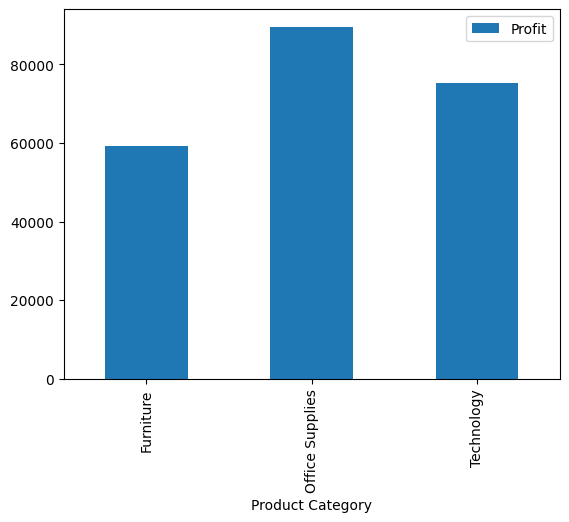

In [252]:
profit_distribution = orders.groupby('Product Category')['Profit'].sum().reset_index()
profit_distribution.plot(kind = 'bar', x = 'Product Category')
plt.show()

In [238]:
product_sub_category_kruskal(column, 'Profit')

,Source,ddof1,H,p_unc,Product Category,Judgement
0,Product Sub-Category,8,32.374384,7.980185e-05,Office Supplies,Rejected
1,Product Sub-Category,3,36.210230,6.759839e-08,Furniture,Rejected
2,Product Sub-Category,3,14.932541,1.875214e-03,Technology,Rejected


**Interpretation**
- The Kruskal-Wallis test indicates that profit differs significantly across product sub-categories within all three product categories.
- Office Supplies exhibited significant variation in profitability among its sub-categories (H = 32.374, p < 0.001), suggesting that some office products generate substantially higher profits than others.
- Furniture also showed significant differences in profitability (H = 36.210, p < 0.001), indicating that not all furniture products contribute equally to business profit.
- Technology demonstrated statistically significant differences as well (H = 14.933, p = 0.0019), although the magnitude of variation was comparatively smaller than that observed in Office Supplies and Furniture.
- Since all Kruskal-Wallis tests were statistically significant, Dunn's post-hoc test was conducted to identify the specific product sub-categories responsible for these differences.

**Business Insights**  
- Profitability is not evenly distributed across product sub-categories within any major product category.
- High sales volumes do not necessarily translate into high profitability, reinforcing the importance of evaluating profit alongside revenue.
- Certain sub-categories contribute disproportionately to overall business profit, while others may generate relatively low returns despite comparable sales activity.
- Product-level profitability analysis provides a more accurate basis for business decisions than evaluating only broad product categories.

**Business Recommendations**  
- Use the Dunn's post-hoc analysis to identify the most and least profitable product sub-categories within each major category.
- Prioritise inventory investment, promotional campaigns, and pricing strategies for the highest-profit sub-categories.
- Review low-profit sub-categories to identify opportunities for cost reduction, supplier negotiation, pricing optimisation, or product rationalisation.
- Monitor both Sales and Profit simultaneously when evaluating product performance to ensure revenue growth also translates into improved profitability.
- Continuously assess sub-category performance to optimise the product portfolio and maximise overall business profitability.

In [253]:
sales_posthoc = product_sub_category_posthoc(column, 'Profit')

sales_posthoc[sales_posthoc['Judgement'] == 'Significant']

,Sub-Category 1,Sub-Category 2,Adjusted p-value,Product Category,Judgement
20,Envelopes,Storage & Organization,0.004014,Office Supplies,Significant
21,Labels,Paper,0.035732,Office Supplies,Significant
25,Labels,Storage & Organization,0.000028,Office Supplies,Significant
32,Pens & Art Supplies,Storage & Organization,0.039991,Office Supplies,Significant
36,Bookcases,Chairs & Chairmats,0.004387,Furniture,Significant
37,Bookcases,Office Furnishings,0.036417,Furniture,Significant
40,Chairs & Chairmats,Tables,0.000001,Furniture,Significant
41,Office Furnishings,Tables,0.000011,Furniture,Significant
44,Computer Peripherals,Telephones and Communication,0.004854,Technology,Significant


# 8. Does an Association Exist Between the Business Categorical Variables?
**Objective**
The objective of this analysis is to determine whether statistically significant associations exist between the major categorical business variables within the Super Store dataset. Understanding these relationships helps identify dependencies between customer segments, shipping methods, product classifications, and geographical regions, enabling better business planning, customer segmentation, inventory management, and logistics optimization.

**Null Hypothesis (H₀)** There is no statistically significant association between the two categorical variables being compared. Any observed relationship is due to random chance.

**Alternative Hypothesis (H₁)** There is a statistically significant association between the two categorical variables, indicating that the distribution of one variable depends on the other.

**Assumption Check**  
Prior to interpreting the Chi-square Test of Independence, the test assumptions were evaluated. Following standard statistical guidelines, each analysis was considered valid when:
No expected cell frequency was less than 1.
No more than 20% of expected cell frequencies were below 5.
Tests that violated these assumptions were excluded from interpretation to ensure the reliability of the statistical conclusions.

In [248]:
from itertools import combinations

columns = ['Ship Mode', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Region', 'State or Province']

def chi2_all_pairs(data, columns):

    result = []

    for x, y in combinations(columns, 2):

        expected, observed, stats = pg.chi2_independence(
            data=data,
            x=x,
            y=y
        )

        # ----------------------------
        # Chi-square assumption check
        # ----------------------------
        low_expected_pct = ((expected < 5).sum().sum() / expected.size) * 100
        min_expected = expected.min().min()

        pearson = stats.loc[stats['test'] == 'pearson'].copy()

        pearson['Variables'] = f'{x} ↔ {y}'
        pearson['Low Expected %'] = round(low_expected_pct, 2)
        pearson['Minimum Expected'] = round(min_expected, 2)

        pearson['Assumption'] = np.where(
            (low_expected_pct <= 20) & (min_expected >= 1),
            'Met',
            'Violated'
        )

        pearson['Judgement'] = np.where(
            pearson['pval'] <= 0.05,
            'Rejected',
            'Fail to Reject'
        )

        result.append(pearson)

    return pd.concat(result, ignore_index=True)

chi2_results = chi2_all_pairs(orders, columns)
chi2_results

C:\Users\Adity\anaconda3\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
C:\Users\Adity\anaconda3\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on expected frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
C:\Users\Adity\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7409: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
C:\Users\Adity\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7409: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
C:\Users\Adity\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:7406: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)
C:\Users\Adity\anaconda3\Lib\site-packages\pingouin\contingency.py:152: UserWarning: Low count on observed frequencies.
  w

,test,lambda,chi2,dof,pval,cramer,power,Variables,Low Expected %,Minimum Expected,Assumption,Judgement
0,pearson,1.0,3.375418,6.0,7.604642e-01,0.029404,0.128923,Ship Mode ↔ Customer Segment,0.00,47.70,Met,Fail to Reject
1,pearson,1.0,549.477324,4.0,1.327434e-117,0.375163,1.000000,Ship Mode ↔ Product Category,0.00,49.18,Met,Rejected
2,pearson,1.0,1500.390388,32.0,1.637726e-295,0.619937,1.000000,Ship Mode ↔ Product Sub-Category,9.80,2.21,Met,Rejected
3,pearson,1.0,7.171096,6.0,3.053139e-01,0.042859,0.242842,Ship Mode ↔ Region,0.00,54.34,Met,Fail to Reject
4,pearson,1.0,102.288707,96.0,3.112960e-01,0.161867,0.921412,Ship Mode ↔ State or Province,43.54,0.25,Violated,Fail to Reject
5,pearson,1.0,8.863549,6.0,1.813987e-01,0.047648,0.298292,Customer Segment ↔ Product Category,0.00,79.51,Met,Fail to Reject
6,pearson,1.0,55.778642,48.0,2.055662e-01,0.097596,0.518806,Customer Segment ↔ Product Sub-Category,4.41,3.58,Met,Fail to Reject
7,pearson,1.0,53.336420,9.0,2.523475e-08,0.095436,0.857945,Customer Segment ↔ Region,0.00,87.86,Met,Rejected
8,pearson,1.0,394.792616,144.0,3.184230e-25,0.259647,0.999977,Customer Segment ↔ State or Province,36.22,0.40,Violated,Rejected
9,pearson,1.0,3904.000000,32.0,0.000000e+00,1.000000,1.000000,Product Category ↔ Product Sub-Category,3.92,3.69,Met,Rejected


**Interpretation**  
- The Chi-square Test of Independence identified statistically significant associations between Ship Mode and Product Category, Ship Mode and Product Sub-Category, and Customer Segment and Region.
- A moderate association was observed between Ship Mode and Product Category (Cramer's V = 0.375), indicating that shipping methods differ depending on the product category being purchased.
- A strong association was identified between Ship Mode and Product Sub-Category (Cramer's V = 0.620), suggesting that shipping preferences vary considerably across different product types.
- Although Customer Segment and Region showed a statistically significant relationship (p < 0.001), the effect size was weak (Cramer's V = 0.095), indicating that the practical association between these variables is limited.
- No statistically significant associations were observed between Ship Mode and Customer Segment, Ship Mode and Region, Customer Segment and Product Category, Customer Segment and Product Sub-Category, Product Category and Region, or Product Sub-Category and Region, suggesting that these variables operate largely independently within the dataset.

**Business Insights**  
- Shipping strategy appears to be primarily influenced by the type of products purchased rather than by customer demographics or geographical regions.
- Different product categories and sub-categories likely require different shipping methods due to variations in product size, weight, fragility, or delivery requirements.
- Customer purchasing behaviour across product categories remains relatively consistent regardless of customer segment, indicating that all customer groups purchase a similar mix of products.
- Regional differences have minimal influence on product category demand, suggesting a relatively consistent product portfolio across the company's operating regions.
- Although customer segment distribution varies slightly across regions, the weak effect size indicates that regional customer composition is broadly similar throughout the business.

**Business Recommendations**  
- Continue optimising shipping operations based on product characteristics rather than applying uniform shipping strategies across all products.
- Develop logistics and fulfilment processes tailored to specific product categories and sub-categories to improve delivery efficiency and customer satisfaction.
- Maintain consistent product offerings across customer segments and regions, as no substantial differences in purchasing patterns were identified.
- Monitor customer segment distribution across regions to identify emerging market opportunities, while recognising that the current regional differences are relatively small.
- Exclude statistical interpretations for variable pairs that violated the Chi-square assumptions or represented deterministic hierarchical relationships (e.g., Product Category ↔ Product Sub-Category and Region ↔ State or Province) to ensure robust and reliable business conclusions.

# 9. Analysis of Returned Orders
**Objective**  
The objective of this analysis is to examine the characteristics of returned orders and identify any observable patterns that may help understand product returns and support future improvements in inventory management, product quality, and customer satisfaction.

**Methodology**  
After joining the Orders and Returns datasets using an inner join on Order ID, only 15 returned orders were identified.
Due to the limited sample size (n = 15), inferential statistical analyses were not performed. Statistical hypothesis tests require an adequate sample size to produce reliable and meaningful conclusions. Therefore, this analysis focuses on descriptive statistics and exploratory observations.

In [254]:
returns.head()

,Order ID,Status
0,65,Returned
1,612,Returned
2,614,Returned
3,678,Returned
4,710,Returned


In [255]:
returned_orders = orders.merge(returns, on = 'Order ID', how = 'inner')
returned_orders.shape

(15, 23)

In [258]:
returned_pc = returned_orders['Product Category'].value_counts(normalize = True).reset_index()

returned_pc

,Product Category,proportion
0,Office Supplies,0.733333
1,Technology,0.133333
2,Furniture,0.133333


In [259]:
rd = returned_orders.groupby('Region')['Row ID'].count()
rd = pd.DataFrame(rd)
rd

,Row ID
Region,
East,7
West,8
